In [1]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split

try:
    import pyarabic.araby as araby
    PYARABIC_AVAILABLE = True
    print("pyarabic loaded ✓")
except ImportError:
    PYARABIC_AVAILABLE = False
    print("pyarabic not found — using regex fallback")
    
print("Ready.")

pyarabic loaded ✓
Ready.


In [2]:
df_raw = pd.read_csv("../data/raw/official_ASAD.csv")

# Rename to standard column names used throughout the project
df_raw = df_raw.rename(columns={"Text": "text", "sentiment": "label"})
df_raw = df_raw[["text", "label"]]   # drop Tweet_id — not needed for modeling

print(f"Shape  : {df_raw.shape}")
print(f"Labels : {df_raw['label'].unique().tolist()}")
print(f"\nLabel distribution:")
print(df_raw["label"].value_counts())
df_raw.head(5)

Shape  : (73614, 2)
Labels : ['neutral', 'negative', 'positive']

Label distribution:
label
neutral     50527
negative    11637
positive    11450
Name: count, dtype: int64


,text,label
0,الزعل بيغير ملامحك بيغير نظرة العين بيغير شك...,neutral
1,@halgawi @DmfMohe ليس حباً في ايران بقدر ماهو ...,neutral
2,@adalfahadduwail أبي أعرف الحاكم العربي المسلم...,neutral
3,@sarmadbouchamou @DimaSadek في الخطاب تبع سليم...,neutral
4,@FofaMahmouddd مفيش الكلام ده في الزمن,neutral


In [3]:
def remove_diacritics(text):
    if PYARABIC_AVAILABLE:
        return araby.strip_tashkeel(text)
    return re.sub(r'[\u0610-\u061A\u064B-\u065F\u0670]', '', text)


def clean_arabic_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)           # URLs
    text = re.sub(r'@\w+', '', text)                        # mentions
    text = re.sub(r'#\w+', '', text)                        # hashtags
    text = re.sub(r'\d+', '', text)                         # numbers
    text = re.sub(                                           # emojis
        r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF'
        r'\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF]+',
        '', text, flags=re.UNICODE)
    text = remove_diacritics(text)
    text = re.sub(r'[إأآ]', 'ا', text)                     # Alef normalization
    text = re.sub(r'ة', 'ه', text)                          # Teh Marbuta
    text = re.sub(r'ى', 'ي', text)                          # Yeh normalization
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)        # keep Arabic only
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Sanity check on real samples
for t in df_raw["text"].head(3).tolist():
    print(f"Before: {t}")
    print(f"After : {clean_arabic_text(t)}\n")

Before: الزعل بيغير ملامحك  بيغير نظرة العين  بيغير شكلك في الصور  الزعل ممكن يطفيك تماما.
After : الزعل بيغير ملامحك بيغير نظره العين بيغير شكلك في الصور الزعل ممكن يطفيك تماما

Before: @halgawi @DmfMohe ليس حباً في ايران بقدر ماهو نكايه بترامب وحزبه
After : ليس حبا في ايران بقدر ماهو نكايه بترامب وحزبه

Before: @adalfahadduwail أبي أعرف الحاكم العربي المسلم أشلون ينام مايخاف الله وهو يسمح في بلده الدعاره والمراقص
After : ابي اعرف الحاكم العربي المسلم اشلون ينام مايخاف الله وهو يسمح في بلده الدعاره والمراقص



In [4]:
df = df_raw.copy()
df["clean_text"] = df["text"].apply(clean_arabic_text)
df["word_count"]  = df["clean_text"].apply(lambda x: len(x.split()))
df["char_count"]  = df["clean_text"].apply(len)

# Drop rows that became empty after cleaning
before = len(df)
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)
print(f"Dropped {before - len(df)} empty rows after cleaning")
print(f"Final dataset: {len(df):,} samples")
df[["text", "clean_text", "label", "word_count"]].head(5)

Dropped 6 empty rows after cleaning
Final dataset: 73,608 samples


,text,clean_text,label,word_count
0,الزعل بيغير ملامحك بيغير نظرة العين بيغير شك...,الزعل بيغير ملامحك بيغير نظره العين بيغير شكلك...,neutral,14
1,@halgawi @DmfMohe ليس حباً في ايران بقدر ماهو ...,ليس حبا في ايران بقدر ماهو نكايه بترامب وحزبه,neutral,9
2,@adalfahadduwail أبي أعرف الحاكم العربي المسلم...,ابي اعرف الحاكم العربي المسلم اشلون ينام مايخا...,neutral,15
3,@sarmadbouchamou @DimaSadek في الخطاب تبع سليم...,في الخطاب تبع سليم سعاده حطت عالتويتر شو قال ق...,neutral,19
4,@FofaMahmouddd مفيش الكلام ده في الزمن,مفيش الكلام ده في الزمن,neutral,5


In [5]:
print("Label distribution:")
for label, count in df["label"].value_counts().items():
    pct = count / len(df) * 100
    print(f"  {label:<10} {count:>6,}  ({pct:.1f}%)")

print("\nWord count per label:")
print(df.groupby("label")["word_count"].describe().round(2).to_string())

Label distribution:
  neutral    50,523  (68.6%)
  negative   11,637  (15.8%)
  positive   11,448  (15.6%)

Word count per label:
            count   mean   std  min  25%   50%   75%   max
label                                                     
negative  11637.0  13.06  5.00  1.0  9.0  12.0  17.0  31.0
neutral   50523.0  13.27  4.99  1.0  9.0  13.0  17.0  35.0
positive  11448.0  12.10  4.98  1.0  8.0  11.0  15.0  30.0


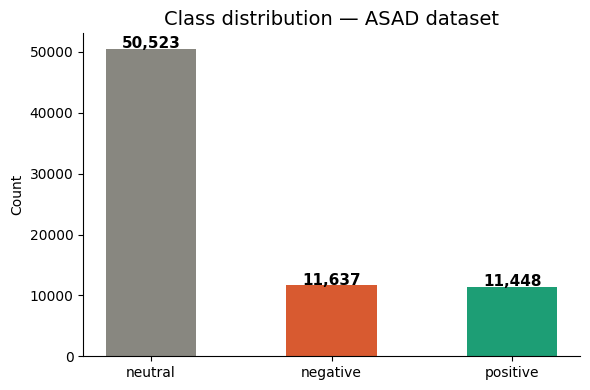

In [6]:
LABEL_COLORS = {"positive": "#1D9E75", "negative": "#D85A30", "neutral": "#888780"}

counts = df["label"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values,
              color=[LABEL_COLORS[l] for l in counts.index],
              width=0.5, edgecolor='none')
for bar, n in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{n:,}", ha='center', fontsize=11, fontweight='bold')
ax.set_title("Class distribution — ASAD dataset", fontsize=14)
ax.set_ylabel("Count")
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("../results/class_distribution.png", dpi=150)
plt.show()

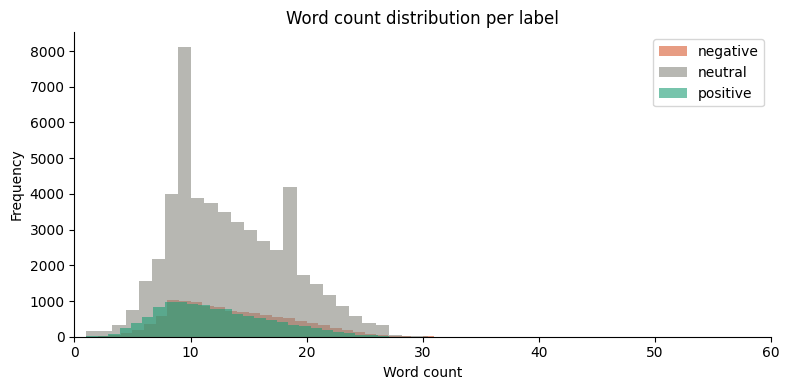

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, group in df.groupby("label"):
    ax.hist(group["word_count"], bins=30, alpha=0.6,
            label=label, color=LABEL_COLORS[label])
ax.set_title("Word count distribution per label")
ax.set_xlabel("Word count")
ax.set_ylabel("Frequency")
ax.set_xlim(0, 60)   # tweets rarely exceed 60 words
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("../results/word_count_dist.png", dpi=150)
plt.show()

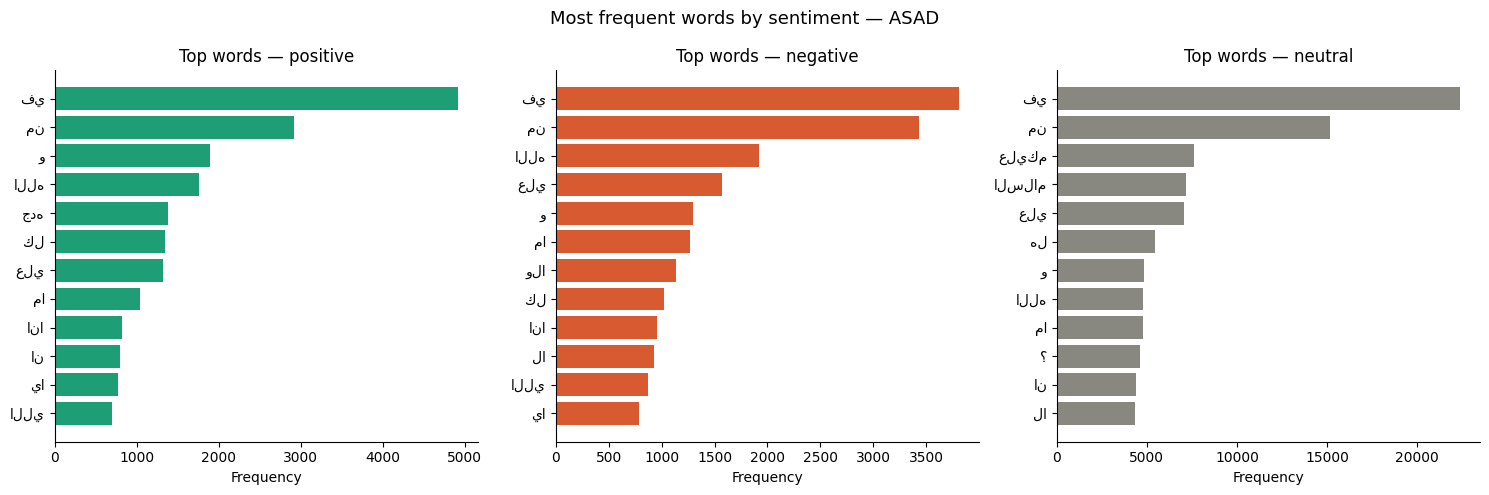

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, label in zip(axes, ["positive", "negative", "neutral"]):
    words = " ".join(df[df["label"] == label]["clean_text"]).split()
    common = Counter(words).most_common(12)
    w, c = zip(*common)
    ax.barh(w[::-1], c[::-1], color=LABEL_COLORS[label], edgecolor='none')
    ax.set_title(f"Top words — {label}")
    ax.set_xlabel("Frequency")
    ax.spines[['top', 'right']].set_visible(False)
plt.suptitle("Most frequent words by sentiment — ASAD", fontsize=13)
plt.tight_layout()
plt.savefig("../results/top_words.png", dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Stratified split to preserve class imbalance across all sets
train_val, test = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42)
train, val = train_test_split(
    train_val, test_size=0.125, stratify=train_val["label"], random_state=42)

print(f"Train : {len(train):>6,}  {train['label'].value_counts().to_dict()}")
print(f"Val   : {len(val):>6,}  {val['label'].value_counts().to_dict()}")
print(f"Test  : {len(test):>6,}  {test['label'].value_counts().to_dict()}")

train.to_csv("../data/train.csv", index=False)
val.to_csv("../data/val.csv",     index=False)
test.to_csv("../data/test.csv",   index=False)
print("\nSplits saved ✓")

Train : 51,525  {'neutral': 35366, 'negative': 8146, 'positive': 8013}
Val   :  7,361  {'neutral': 5052, 'negative': 1164, 'positive': 1145}
Test  : 14,722  {'neutral': 10105, 'negative': 2327, 'positive': 2290}

Splits saved ✓
